In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, roc_auc_score, ConfusionMatrixDisplay, classification_report


In [3]:
df = pd.read_csv("../data/heart_cleaned.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,country,clinical_index
0,28.0,1.0,2.0,130.0,132.0,0.0,2.0,185.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-3.920000
1,29.0,1.0,2.0,120.0,243.0,0.0,0.0,160.0,0.0,0.0,NaN,NaN,NaN,1,Hungary,-0.670000
2,29.0,1.0,2.0,140.0,241.0,0.0,0.0,170.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-1.947393
3,30.0,0.0,1.0,170.0,237.0,0.0,1.0,170.0,0.0,0.0,NaN,NaN,6.0,0,Hungary,-1.160000
4,31.0,0.0,2.0,100.0,219.0,0.0,1.0,150.0,0.0,0.0,NaN,NaN,NaN,0,Hungary,-0.690000


In [4]:
df.shape

(918, 16)

In [5]:
df.isna().sum().sort_values(ascending=False)

ca                609
thal              484
slope             308
age                 0
chol                0
sex                 0
cp                  0
trestbps            0
thalach             0
restecg             0
fbs                 0
oldpeak             0
exang               0
target              0
country             0
clinical_index      0
dtype: int64

Baseline model without high-missing variables.
Model A

In [6]:
df_model = df.drop(columns=["thal", "slope", "ca"])

In [7]:
X = df_model.drop(columns=["target"])
y = df_model["target"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [9]:
categorial_features = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country"
]

numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [10]:
preprocessor = ColumnTransformer(
    transformers = [
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first"), categorial_features)
    ]
)

In [11]:
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [12]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [13]:
y_pred = model.predict(X_test)

## Model Predictions

After training the baseline Logistic Regression model, predictions were generated on the test dataset. These predictions will be used to evaluate model performance.

In [14]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy score: ", accuracy)

Accuracy score:  0.7554347826086957


Accuracy

Accuracy measures the proportion of correct predictions among all test observations.

It is calculated as:

correct predictions / all predictions

Accuracy is useful as a first overview, but it can be misleading if the classes are imbalanced.

In [15]:
precision = precision_score(y_test, y_pred)
print("Precision score: ", precision)

Precision score:  0.7894736842105263



Precision measures how many patients predicted as having heart disease actually have heart disease.

A high precision means that when the model predicts heart disease, it is usually correct.

 Precision

The baseline model achieved a precision score of 0.78.

This means that approximately 78% of patients predicted as having heart disease were correctly classified. The model produces relatively few false positive predictions.

In [16]:
recall = recall_score(y_test, y_pred)
print("Recall score: ", recall)

Recall score:  0.75


Recall

The baseline model achieved a recall score of 0.75.

This indicates that approximately 75% of patients with heart disease were correctly identified by the model. In other words, the model missed around 25% of actual heart disease cases.

Since heart disease detection is a medical classification task, recall is an important metric because false negatives may have serious consequences.

In [17]:
f1 = f1_score(y_test, y_pred)
print("F1 score: ", f1)

F1 score:  0.7692307692307693


F1 Score

The baseline model achieved an F1 score of 0.77.

The F1 score combines precision and recall into a single metric and is particularly useful when evaluating classification models in healthcare settings.

The relatively balanced precision (0.78) and recall (0.75) resulted in a strong overall F1 score, indicating a balanced classification performance.

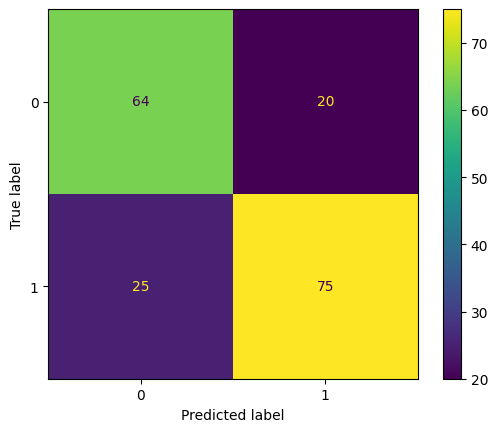

In [18]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

## Confusion Matrix Interpretation

The baseline model correctly identified:

- 64 healthy patients (True Negatives)
- 75 patients with heart disease (True Positives)

The model incorrectly classified:

- 20 healthy patients as having heart disease (False Positives)
- 25 heart disease patients as healthy (False Negatives)

The confusion matrix shows that the model is reasonably balanced, with similar numbers of false positives and false negatives. However, the 25 missed heart disease cases suggest that there is still room for improvement, particularly in recall.

In [19]:
y_prob = model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC score: ", roc_auc)

ROC-AUC score:  0.8341666666666666


## ROC-AUC Score

The baseline Logistic Regression model achieved a ROC-AUC score of 0.83.

This indicates good discriminative performance. In practical terms, the model has approximately an 83% probability of assigning a higher risk score to a patient with heart disease than to a healthy patient.

Among all evaluation metrics, ROC-AUC provides one of the most informative assessments of overall classification performance because it evaluates the quality of probability rankings rather than a single classification threshold.

# Model B: Including Slope

In this experiment, the `slope` variable is retained to evaluate whether the additional information improves predictive performance compared to the baseline model.

In [20]:
df_model_b = df.drop(columns=["thal", "ca"])

In [21]:
df_model_b.isna().sum()

age                 0
sex                 0
cp                  0
trestbps            0
chol                0
fbs                 0
restecg             0
thalach             0
exang               0
oldpeak             0
slope             308
target              0
country             0
clinical_index      0
dtype: int64

In [22]:
df_model_b["slope"] = df_model_b["slope"].fillna(0)

In [23]:
df_model_b["slope"].value_counts()

slope
2.0    345
0.0    308
1.0    202
3.0     63
Name: count, dtype: int64

## Slope Missing Value Strategy

The slope variable contained approximately 34% missing values.

Instead of using mode imputation, missing values were assigned to a separate category (0). This approach preserves the information that the measurement was unavailable and avoids artificially inflating the frequency of existing categories.

In [24]:
X_b = df_model_b.drop(columns=["target"])
y_b = df_model_b["target"]

## Feature Selection

The slope variable was reintroduced into the dataset.

Missing slope values were assigned to a separate category (0) to preserve information about unavailable measurements.

In [25]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b,
    y_b,
    test_size=0.2,
    random_state=42,
    stratify=y_b
)

In [26]:
categorical_features_b = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country",
    "slope"
]

numerical_features_b = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [27]:
preprocessor_b = ColumnTransformer(
    transformers = [
        ("num_b", StandardScaler(), numerical_features_b),
        ("cat_b", OneHotEncoder(drop="first"), categorical_features_b)
    ]
)

In [28]:
model_B = Pipeline([
    ("preprocessor", preprocessor_b),
    ("classifier", LogisticRegression(max_iter=1000))
]
)

## Training Model B

A Logistic Regression model was trained using the baseline feature set together with the slope variable.

In [29]:
model_B.fit(X_train_b, y_train_b)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_b', ...), ('cat_b', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [30]:
y_pred_b = model_B.predict(X_test_b)

In [31]:
accuracy_b = accuracy_score(y_test_b, y_pred_b)
precision_b = precision_score(y_test_b, y_pred_b)
recall_b = recall_score(y_test_b, y_pred_b)
f1_b = f1_score(y_test_b, y_pred_b)

print("Accuracy score of model with slope: ", accuracy_b)
print("Precision score of model with slope: ", precision_b)
print("Recall Score of model with slope: ", recall_b)
print("F1 score of model with slope: ", f1_b)

Accuracy score of model with slope:  0.7663043478260869
Precision score of model with slope:  0.7938144329896907
Recall Score of model with slope:  0.77
F1 score of model with slope:  0.7817258883248731


In [32]:
y_prob_b = model_B.predict_proba(X_test_b)[:, 1]
roc_auc_b = roc_auc_score(y_test_b, y_prob_b)
print("ROC-AUC score of model with slope: ", roc_auc_b)

ROC-AUC score of model with slope:  0.8397619047619048


## Updated Model B Results

After correctly treating slope as a categorical variable, model performance improved across most evaluation metrics.

Compared with the baseline model:

- Accuracy increased from 0.75 to 0.77.
- Recall increased from 0.75 to 0.77.
- F1 score improved from 0.77 to 0.78.
- ROC-AUC increased from 0.834 to 0.840.

These results suggest that slope contains useful predictive information and may improve heart disease classification when missing values are handled appropriately.

# Model C: Including Thal

The thal variable showed one of the strongest relationships with heart disease during exploratory analysis. However, more than half of the observations are missing.

This experiment evaluates whether retaining thal improves predictive performance despite the high level of missing data.

In [33]:
df["thal"].value_counts(dropna=False)

thal
NaN    484
3.0    196
7.0    192
6.0     46
Name: count, dtype: int64

In [34]:
df_model_c = df.drop(columns=["slope", "ca"])

In [35]:
df_model_c.isna().sum()

age                 0
sex                 0
cp                  0
trestbps            0
chol                0
fbs                 0
restecg             0
thalach             0
exang               0
oldpeak             0
thal              484
target              0
country             0
clinical_index      0
dtype: int64

In [36]:
df_model_c["thal"] = df_model_c["thal"].fillna(0)

In [37]:
df_model_c["thal"].value_counts()

thal
0.0    484
3.0    196
7.0    192
6.0     46
Name: count, dtype: int64

In [38]:
X_c = df_model_c.drop(columns=["target"])
y_c = df_model_c["target"]

In [39]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_c,
    y_c,
    test_size = 0.2,
    random_state = 42,
    stratify = y_c 
)

In [40]:
categorical_features_c = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country",
    "thal"
]

numerical_features_c = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [41]:
preprocessor_c = ColumnTransformer(
    transformers = [
        ("num_c", StandardScaler(), numerical_features_c),
        ("cat_c", OneHotEncoder(drop="first"), categorical_features_c)
    ]
)

In [42]:
model_c = Pipeline([
    ("preprocessor", preprocessor_c),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [43]:
model_c.fit(X_train_c, y_train_c)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_c', ...), ('cat_c', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [44]:
y_pred_c = model_c.predict(X_test_c)

In [45]:
accuracy_c = accuracy_score(y_test_c, y_pred_c)
precision_c = precision_score(y_test_c, y_pred_c)
recall_c = recall_score(y_test_c, y_pred_c)
f1_c = f1_score(y_test_c, y_pred_c)

print("Accuracy :", accuracy_c)
print("Precision:", precision_c)
print("Recall   :", recall_c)
print("F1 Score :", f1_c)

Accuracy : 0.7771739130434783
Precision: 0.8105263157894737
Recall   : 0.77
F1 Score : 0.7897435897435897


In [46]:
y_prob_c = model_c.predict_proba(X_test_c)[:,1]

roc_auc_c = roc_auc_score(y_test_c, y_prob_c)

print("ROC-AUC:", roc_auc_c)

ROC-AUC: 0.8386904761904762


In [47]:
df_model_c["thal"].value_counts()

thal
0.0    484
3.0    196
7.0    192
6.0     46
Name: count, dtype: int64

## Model C Results

Including the thal variable improved overall classification performance compared with the baseline model.

Model C achieved the highest accuracy (0.78) and F1 score (0.79) among the tested models. However, the ROC-AUC score remained very similar to Model B.

These results suggest that thal contains useful predictive information, although the benefit is partially limited by the large proportion of missing values.

Model B and Model C both improved upon the baseline model.

The inclusion of slope increased ROC-AUC and recall, while the inclusion of thal produced the highest accuracy and F1 score.

The differences between Model B and Model C were relatively small, suggesting that both variables contain useful information but provide only modest improvements beyond the baseline feature set.

# Model D: Including Both Slope and Thal

In [48]:
df_model_d = df.drop(columns=["ca"])

In [49]:
df_model_d["slope"] = df_model_d["slope"].fillna(0)
df_model_d["thal"] = df_model_d["thal"].fillna(0)

In [54]:
df_model_d.isna().sum()

age               0
sex               0
cp                0
trestbps          0
chol              0
fbs               0
restecg           0
thalach           0
exang             0
oldpeak           0
slope             0
thal              0
target            0
country           0
clinical_index    0
dtype: int64

In [55]:
X_d = df_model_d.drop(columns=["target"])
y_d = df_model_d["target"]

In [56]:
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_d,
    y_d,
    test_size=0.2,
    random_state=42,
    stratify=y_d
)

In [57]:
categorical_features_d = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country",
    "slope",
    "thal"
]
numerical_features_d = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [58]:
preprocessor_d = ColumnTransformer(
    transformers=([
        ("num_d", StandardScaler(), numerical_features_d),
        ("cat_d", OneHotEncoder(drop = "first"), categorical_features_d)
    ])
)

In [59]:
model_d = Pipeline([
    ("preprocessor", preprocessor_d),
    ("classifier", LogisticRegression(max_iter=1000))
])

In [61]:
model_d.fit(X_train_d, y_train_d)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_d', ...), ('cat_d', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

# Model D: Including Both Slope and Thal

This model combines the two high-missing variables that demonstrated potential predictive value during exploratory analysis.

Missing values in both variables were treated as separate categories to preserve information regarding unavailable measurements.

In [62]:
y_pred_d = model_d.predict(X_test_d)

In [63]:
accuracy_d = accuracy_score(y_test_d, y_pred_d)
precision_d = precision_score(y_test_d, y_pred_d)
recall_d = recall_score(y_test_d, y_pred_d)
f1_d = f1_score(y_test_d, y_pred_d)

print("Accuracy :", accuracy_d)
print("Precision:", precision_d)
print("Recall   :", recall_d)
print("F1 Score :", f1_d)

Accuracy : 0.7717391304347826
Precision: 0.7959183673469388
Recall   : 0.78
F1 Score : 0.7878787878787878


In [64]:
y_prob_d = model_d.predict_proba(X_test_d)[:, 1]
roc_auc_d = roc_auc_score(y_test_d, y_prob_d)
print("ROC-AUC score: ", roc_auc_d)

ROC-AUC score:  0.8420238095238095


## Model Comparison

Four Logistic Regression models were evaluated.

Model D, which included both slope and thal, achieved the highest ROC-AUC score (0.842) and the highest recall (0.78), indicating the strongest ability to identify patients with heart disease.

Although Model C achieved slightly higher accuracy and precision, the overall balance of performance metrics suggests that Model D provides the best predictive performance among the evaluated models.

# Model E: Including CA

The ca variable showed a moderate correlation with the target variable during exploratory analysis. However, approximately 66% of observations were missing.

This experiment evaluates whether retaining ca improves predictive performance despite the large amount of missing data.

In [65]:
df_model_e = df.drop(columns=["slope", "thal"])

In [66]:
df_model_e["ca"].value_counts(dropna=False)

ca
NaN    609
0.0    181
1.0     67
2.0     41
3.0     20
Name: count, dtype: int64

# Model E: Including CA

The CA variable showed a moderate relationship with heart disease during exploratory analysis (correlation ≈ 0.36). However, approximately 66% of observations contained missing values.

Using mode imputation would substantially distort the original distribution of the variable because the majority of missing values would be assigned to the most common category.

Instead, missing values were assigned to a separate category (-1). This approach preserves the information that the measurement was unavailable while avoiding artificial inflation of existing categories.

The CA variable was then treated as a categorical feature during model training.

In [68]:
df_model_e["ca"] = df_model_e["ca"].fillna(-1)
df_model_e["ca"].value_counts()

ca
-1.0    609
 0.0    181
 1.0     67
 2.0     41
 3.0     20
Name: count, dtype: int64

In [69]:
X_e = df_model_e.drop(columns=["target"])
y_e = df_model_e["target"]

In [70]:
X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(
    X_e,
    y_e,
    test_size=0.2,
    random_state=42,
    stratify=y_e
)

In [71]:
categorical_features_e = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country",
    "ca"
]

numerical_features_e = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [72]:
preprocessor_e = ColumnTransformer(
    transformers=([
        ("num_e", StandardScaler(), numerical_features_e),
        ("cat_e", OneHotEncoder(drop="first"), categorical_features_e)
    ])
)

In [73]:
model_e = Pipeline([
    ("prepocessor", preprocessor_e),
    ("classifier", LogisticRegression(max_iter=1000))
]
)

In [74]:
model_e.fit(X_train_e, y_train_e)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_e', ...), ('cat_e', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [75]:
y_pred_e = model_e.predict(X_test_e)

In [76]:
accuracy_e = accuracy_score(y_test_e, y_pred_e)
precision_e = precision_score(y_test_e, y_pred_e)
recall_e = recall_score(y_test_e, y_pred_e)
f1_e = f1_score(y_test_e, y_pred_e)

print("Accuracy :", accuracy_e)
print("Precision:", precision_e)
print("Recall   :", recall_e)
print("F1 Score :", f1_e)

Accuracy : 0.7608695652173914
Precision: 0.8181818181818182
Recall   : 0.72
F1 Score : 0.7659574468085106


In [79]:
y_prob_e = model_e.predict_proba(X_test_e) [: , 1]
roc_auc_e = roc_auc_score(y_test_e, y_pred_e)
print("ROC-AUC score: ", roc_auc_e)

ROC-AUC score:  0.7647619047619048


## Model E Results

Although the CA variable demonstrated a moderate correlation with the target variable during exploratory analysis, its inclusion resulted in substantially worse model performance.

The ROC-AUC score decreased from approximately 0.84 to 0.76, while recall also declined.

This suggests that the very high proportion of missing values (approximately 66%) limited the usefulness of the CA feature and introduced additional noise into the model.

Therefore, CA was not retained in the final model despite its apparent relationship with heart disease in the exploratory analysis.

# Model F: Including Slope, Thal and CA

The final experiment includes all three variables with substantial missing values: slope, thal, and ca.

Missing values were represented as separate categories in order to preserve information regarding unavailable measurements while avoiding distributional distortions caused by traditional imputation methods.

The objective is to determine whether the combined information from these variables improves predictive performance beyond the previous models.

In [80]:
df_model_f = df.copy()

In [81]:
df_model_f["slope"] = df_model_f["slope"].fillna(0)

df_model_f["thal"] = df_model_f["thal"].fillna(0)

df_model_f["ca"] = df_model_f["ca"].fillna(-1)

In [83]:
X_f = df_model_f.drop(columns=["target"])
y_f = df_model_f["target"]

In [84]:
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_f,
    y_f,
    test_size=0.2,
    random_state=42,
    stratify=y_f
)

In [85]:
categorical_features_f = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "country",
    "slope",
    "thal",
    "ca"
]
numerical_features_f = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak",
    "clinical_index"
]

In [86]:
preprocessor_f = ColumnTransformer(
    transformers=[
        ("num_f", StandardScaler(), numerical_features_f),
        ("cat_f", OneHotEncoder(drop="first"), categorical_features_f)
    ]
)

In [87]:
model_f = Pipeline([
    ("prepocessor", preprocessor_f),
    ("classifier", LogisticRegression(max_iter=1000))
]
)

In [88]:
model_f.fit(X_train_f, y_train_f)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prepocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num_f', ...), ('cat_f', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfo

In [89]:
y_pred_f = model_f.predict(X_test_f)

In [90]:
accuracy_f = accuracy_score(y_test_f, y_pred_f)
precision_f = precision_score(y_test_f, y_pred_f)
recall_f = recall_score(y_test_f, y_pred_f)
f1_f = f1_score(y_test_f, y_pred_f)

print("Accuracy :", accuracy_f)
print("Precision:", precision_f)
print("Recall   :", recall_f)
print("F1 Score :", f1_f)

Accuracy : 0.7717391304347826
Precision: 0.8152173913043478
Recall   : 0.75
F1 Score : 0.78125


In [91]:
y_prob_f = model_f.predict_proba(X_test_f)[:,1]
roc_auc_f = roc_auc_score(y_test_f, y_prob_f)
print("ROC-AUC  :", roc_auc_f)

ROC-AUC  : 0.8426190476190476


# Final Model Selection

Six Logistic Regression models were evaluated.

Model D, which included both slope and thal, achieved the best overall balance between discrimination and classification performance.

Although Model F achieved a marginally higher ROC-AUC score, the improvement was negligible and was accompanied by lower recall and F1 score.

Therefore, Model D was selected as the final model because it achieved:

- The highest recall (0.78)
- A strong ROC-AUC score (0.842)
- Strong overall classification performance

The CA variable was not retained in the final model because its inclusion did not produce meaningful improvements despite its moderate correlation with the target variable. This is likely due to the very high proportion of missing values (approximately 66%).

In [92]:
results = pd.DataFrame({
    "Model": ["A", "B", "C", "D", "E", "F"],
    "Accuracy": [0.750, 0.766, 0.777, 0.772, 0.761, 0.772],
    "Precision": [0.789, 0.794, 0.811, 0.796, 0.818, 0.815],
    "Recall": [0.750, 0.770, 0.770, 0.780, 0.720, 0.750],
    "F1": [0.769, 0.782, 0.790, 0.788, 0.766, 0.781],
    "ROC_AUC": [0.834, 0.840, 0.839, 0.842, 0.765, 0.843]
})

results

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,A,0.750,0.789,0.75,0.769,0.834
1,B,0.766,0.794,0.77,0.782,0.840
2,C,0.777,0.811,0.77,0.790,0.839
3,D,0.772,0.796,0.78,0.788,0.842
4,E,0.761,0.818,0.72,0.766,0.765
5,F,0.772,0.815,0.75,0.781,0.843


## Interpreting Model Parameters

In Logistic Regression, each coefficient represents the effect of a variable on the log-odds of heart disease.

- Positive coefficients increase predicted risk.
- Negative coefficients decrease predicted risk.
- Larger absolute values indicate stronger effects.

In [94]:
feature_names = model_d.named_steps["preprocessor"].get_feature_names_out()
feature_names

array(['num_d__age', 'num_d__trestbps', 'num_d__chol', 'num_d__thalach',
       'num_d__oldpeak', 'num_d__clinical_index', 'cat_d__sex_1.0',
       'cat_d__cp_2.0', 'cat_d__cp_3.0', 'cat_d__cp_4.0',
       'cat_d__fbs_1.0', 'cat_d__restecg_1.0', 'cat_d__restecg_2.0',
       'cat_d__exang_1.0', 'cat_d__country_Hungary',
       'cat_d__country_Switzerland', 'cat_d__country_VA',
       'cat_d__slope_1.0', 'cat_d__slope_2.0', 'cat_d__slope_3.0',
       'cat_d__thal_3.0', 'cat_d__thal_6.0', 'cat_d__thal_7.0'],
      dtype=object)

In [95]:
coefficients = model_d.named_steps["classifier"].coef_[0]
coefficients

array([ 1.99835451e-01, -4.84790788e-04,  2.40464528e-01, -2.31193063e-01,
        4.97257093e-01, -2.72600199e-01,  5.93487987e-01, -2.98182640e-01,
       -2.57522577e-01,  5.29739541e-01,  3.55890788e-01, -3.80312317e-01,
        6.76894813e-02,  3.10589419e-01, -4.93369190e-01,  1.04821962e+00,
        3.90069757e-01, -4.39361093e-01, -8.91844750e-03, -3.90531482e-01,
       -6.85349076e-01, -2.39739558e-02,  1.37534734e-01])

In [99]:
coef_df = pd.DataFrame({
    "Feature" : feature_names,
    "Coefficient" : coefficients
})

In [100]:
coef_df.sort_values("Coefficient", ascending=False).head(10)

,Feature,Coefficient
15,cat_d__country_Switzerland,1.048220
6,cat_d__sex_1.0,0.593488
9,cat_d__cp_4.0,0.529740
4,num_d__oldpeak,0.497257
16,cat_d__country_VA,0.390070
10,cat_d__fbs_1.0,0.355891
13,cat_d__exang_1.0,0.310589
2,num_d__chol,0.240465
0,num_d__age,0.199835
22,cat_d__thal_7.0,0.137535


In [101]:
coef_df.sort_values("Coefficient").head(10)

,Feature,Coefficient
20,cat_d__thal_3.0,-0.685349
14,cat_d__country_Hungary,-0.493369
17,cat_d__slope_1.0,-0.439361
19,cat_d__slope_3.0,-0.390531
11,cat_d__restecg_1.0,-0.380312
7,cat_d__cp_2.0,-0.298183
5,num_d__clinical_index,-0.272600
8,cat_d__cp_3.0,-0.257523
3,num_d__thalach,-0.231193
21,cat_d__thal_6.0,-0.023974


## Interpretation of Model Parameters

Positive coefficients increase the predicted probability of heart disease, while negative coefficients decrease it.

The strongest positive predictors included:

- Male sex
- Exercise-induced angina (exang)
- Elevated fasting blood sugar (fbs)
- Higher oldpeak values

The strongest negative predictors included:

- Higher maximum heart rate (thalach)
- Certain thal and slope categories

Some coefficients should be interpreted with caution because categorical variables are represented relative to a reference category and several variables may contain overlapping information.

The largest positive coefficient was associated with the Switzerland region indicator.

This suggests that, after accounting for the available clinical variables, patients from the Switzerland dataset were more likely to be classified as having heart disease compared with the reference region.

However, this coefficient should be interpreted cautiously because region variables may capture differences in data collection procedures, patient populations, measurement practices, or other unobserved factors rather than direct biological effects.

## Variables Increasing and Decreasing Risk

Variables associated with increased predicted risk include:

- Male sex
- Higher oldpeak values
- Exercise-induced angina (exang)
- Elevated fasting blood sugar (fbs)
- Certain chest pain categories

Variables associated with decreased predicted risk include:

- Higher maximum heart rate (thalach)
- Certain slope categories
- Certain thal categories

These interpretations are based on the sign and magnitude of the Logistic Regression coefficients.

In [105]:
patient = X_test_d.iloc[[0]]
probability = model_d.predict_proba(patient)[0][1]
print(f"Estimated probability of heart disease: {probability:.2%}")

Estimated probability of heart disease: 9.90%
